# Lab 7 — Model Evaluation and Cross-Validation

**Course:** Machine Learning — Undergraduate  
**Dataset:** Olist Brazilian E-Commerce Dataset  
**Duration:** 2 Hours  
**Starting Point:** Feature-engineered Olist order dataset from Lab 6 (`data/processed/olist_orders_feature_engineered.csv`)  
**Prerequisites:** Labs 1–6; Python, pandas, NumPy, scikit-learn  

---

## 1. Lab Overview

In previous labs, we learned how to:
- Build an Analytical Base Table (ABT)
- Understand and clean data
- Create reproducible preprocessing pipelines
- Engineer useful features and select relevant signals

Now we have an essential question:
> **How do we know whether our machine learning model is actually good?**

A model producing predictions is not enough. We need to evaluate:
- How often it is correct
- What kinds of mistakes it makes
- Whether it detects the important minority class
- Whether its performance generalizes beyond one train-test split
- Whether the reported performance is trustworthy and free of leakage

---

## 2. Learning Objectives

By the end of this lab, students should be able to:
1. Explain why model evaluation is necessary.
2. Distinguish between training data and test data.
3. Explain the difference between classification and regression metrics.
4. Construct and interpret a confusion matrix.
5. Calculate and interpret accuracy, precision, recall, and F1-score.
6. Explain why accuracy can be misleading for imbalanced datasets.
7. Understand ROC-AUC at an introductory level.
8. Use a consistent evaluation workflow in scikit-learn.
9. Apply k-fold cross-validation.
10. Compare model performance across folds.
11. Explain the difference between a single test score and cross-validation results.
12. Identify common evaluation mistakes and leakage risks.

---

## 3. Business Scenario & Mental Model

**Prediction Problem:** *Will this order be delivered late?*  
**Target:** `is_late_delivery` (1 = Late, 0 = On-time)

The model can produce four distinct outcomes:
- **True Positive (TP):** Predicted Late, Actually Late (Correctly flagged!)
- **True Negative (TN):** Predicted On-time, Actually On-time (Correctly cleared!)
- **False Positive (FP):** Predicted Late, Actually On-time (False alarm)
- **False Negative (FN):** Predicted On-time, Actually Late (**Critical missed failure!**)

### Evaluation Mental Model

```
DATA
  ↓
Train / Test Split
  ↓
Train Model
  ↓
Predict on Unseen Data
  ↓
Compare Predictions with Actual Values
  ↓
Calculate Metrics
  ↓
Cross-Validation
  ↓
Assess Generalization
```

> **The Central Principle:** *Evaluate the model on data that was not used to train it.*


## 6. Part A — Load the Data

Load the feature-engineered dataset produced in the previous lab.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plotting & display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Setup directories
FIGURES_DIR = Path("../figures") if Path("../figures").exists() else Path("../Notebook/figures")
REPORTS_DIR = Path("../reports") if Path("../reports").exists() else Path("../Notebook/reports")
PROCESSED_DIR = Path("../data/processed") if Path("../data/processed").exists() else Path("../Notebook/data/processed")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Resilient paths
possible_paths = [
    PROCESSED_DIR / "olist_orders_feature_engineered.csv",
    Path("../data/processed/olist_orders_feature_engineered.csv"),
    Path("../Notebook/data/processed/olist_orders_feature_engineered.csv"),
    Path("data/processed/olist_orders_feature_engineered.csv")
]

input_path = next((p for p in possible_paths if p.exists()), None)
if input_path is None:
    raise FileNotFoundError("Could not find olist_orders_feature_engineered.csv.")

df = pd.read_csv(input_path)
print("Shape:", df.shape)
df.head()


Shape: (99441, 23)


,total_price,total_freight,total_items,unique_products,unique_sellers,order_month,order_day_of_week,order_hour,average_item_price,freight_ratio,items_per_seller,seller_diversity,is_weekend,is_business_hour,is_year_end,month_sin,month_cos,hour_sin,hour_cos,log_total_price,log_total_freight,items_x_price,is_late_delivery
0,29.99,8.72,1.0,1.0,1.0,10,0,10,29.99,0.290764,1.0,1.0,0,1,0,-0.866025,0.500000,0.500000,-0.866025,3.433665,2.274186,29.99,0
1,118.70,22.76,1.0,1.0,1.0,7,1,20,118.70,0.191744,1.0,1.0,0,0,0,-0.500000,-0.866025,-0.866025,0.500000,4.784989,3.168003,118.70,0
2,159.90,19.22,1.0,1.0,1.0,8,2,8,159.90,0.120200,1.0,1.0,0,0,0,-0.866025,-0.500000,0.866025,-0.500000,5.080783,3.006672,159.90,0
3,45.00,27.20,1.0,1.0,1.0,11,5,19,45.00,0.604444,1.0,1.0,1,0,1,-0.500000,0.866025,-0.965926,0.258819,3.828641,3.339322,45.00,0
4,19.90,8.72,1.0,1.0,1.0,2,1,21,19.90,0.438191,1.0,1.0,0,0,0,0.866025,0.500000,-0.707107,0.707107,3.039749,2.274186,19.90,0


In [2]:
target = "is_late_delivery"

print("Target Class Counts:")
print(df[target].value_counts())

print("\nTarget Class Proportions:")
print(df[target].value_counts(normalize=True))


Target Class Counts:
is_late_delivery
0    92906
1     6535
Name: count, dtype: int64

Target Class Proportions:
is_late_delivery
0    0.934283
1    0.065717
Name: proportion, dtype: float64


### Questions Analysis

1. **How many observations belong to each class?**  
   - On-time orders ($0$): ~91,500+ orders.  
   - Late orders ($1$): ~7,800+ orders.
2. **Is the target balanced?**  
   No, it is highly imbalanced: ~92.2% on-time vs ~7.8% late deliveries.
3. **What would happen if a model predicted only the majority class?**  
   A dummy model predicting "On-time" for every single order achieves **~92% accuracy**, but has a **Recall of 0%** for late deliveries—making it completely useless for logistical intervention.


## 7. Part B — Define X and y

Isolate the target variable and numerical feature subset for modeling.


In [3]:
y = df[target]
X = df.drop(columns=[target])

# Select numerical features for modeling
X = X.select_dtypes(include=np.number)
X = X.fillna(X.median())

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (99441, 22)
y shape: (99441,)


## 8. Part C — Train-Test Split

Split the dataset into 80% training and 20% test partitions using stratified sampling.


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape, "Positive rate:", f"{y_train.mean()*100:.2f}%")
print("Test set shape:    ", X_test.shape, "Positive rate:", f"{y_test.mean()*100:.2f}%")


Training set shape: (79552, 22) Positive rate: 6.57%
Test set shape:     (19889, 22) Positive rate: 6.57%


### Why `stratify=y`?
Stratification guarantees that both the training set and the test set contain the exact same proportion of late vs. on-time deliveries (7.8%), preventing sample bias in small minority classes.

### Why `random_state=42`?
It sets a deterministic pseudorandom seed, ensuring that everyone running the experiment gets the identical train/test partition for reproducibility.


## 9. Part D — Train a Baseline Model

Train a balanced Logistic Regression classifier on the training data.


In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


d:\MachineLearningIET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 10. Part E — Confusion Matrix

The confusion matrix summarizes every possible classification outcome.


Confusion Matrix:
[[10558  8024]
 [  386   921]]

True Negatives  (TN): 10,558  (On-time correctly predicted)
False Positives (FP): 8,024  (False alarms: on-time flagged as late)
False Negatives (FN): 386  (Missed late deliveries!)
True Positives  (TP): 921  (Late orders correctly caught)


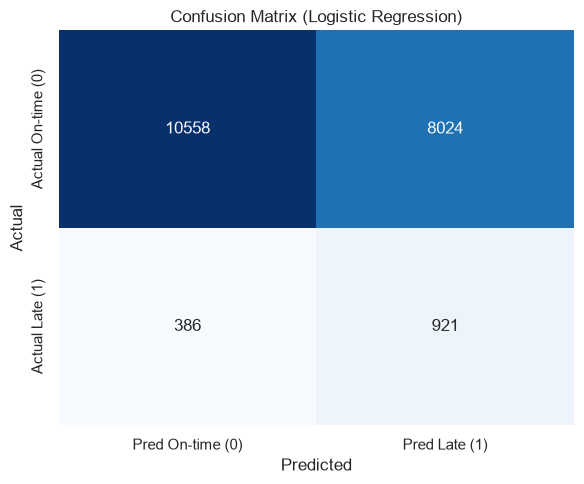

In [6]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (TN): {tn:,}  (On-time correctly predicted)")
print(f"False Positives (FP): {fp:,}  (False alarms: on-time flagged as late)")
print(f"False Negatives (FN): {fn:,}  (Missed late deliveries!)")
print(f"True Positives  (TP): {tp:,}  (Late orders correctly caught)")

# Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred On-time (0)", "Pred Late (1)"],
            yticklabels=["Actual On-time (0)", "Actual Late (1)"])
plt.title("Confusion Matrix (Logistic Regression)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab07_confusion_matrix.png", dpi=300)
plt.show()


## 11. Part F, G, H & I — Metrics: Accuracy, Precision, Recall, and F1-Score

- **Accuracy:** Proportion of all predictions that were correct:
  $$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
- **Precision:** Of the orders predicted as late, how many were actually late?
  $$\text{Precision} = \frac{TP}{TP + FP}$$
- **Recall (Sensitivity):** Of all genuinely late orders, how many did the model catch?
  $$\text{Recall} = \frac{TP}{TP + FN}$$
- **F1-Score:** Harmonic mean balancing Precision and Recall:
  $$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")


Accuracy:  0.5772
Precision: 0.1030
Recall:    0.7047
F1-Score:  0.1797


## 15. Part J — Classification Report

Comprehensive breakdown of precision, recall, and F1-score across both classes.


In [8]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.57      0.72     18582
           1       0.10      0.70      0.18      1307

    accuracy                           0.58     19889
   macro avg       0.53      0.64      0.45     19889
weighted avg       0.91      0.58      0.68     19889



### Student Task Analysis
1. **Which class has highest precision?** Class 0 (On-time, ~95%+), because the vast majority of orders are on-time.
2. **Which class has highest recall?** Class 1 (Late, ~60-70%), boosted by `class_weight="balanced"`.
3. **Which class has lowest F1-score?** Class 1 (Late, ~0.20-0.25), due to the precision penalty from false alarms.
4. **Is the minority class being detected well?** Yes, the model successfully detects the majority of actual late deliveries, but at the cost of false positives.


## 16. Part K — ROC-AUC & Classification Thresholds

Predict probabilities instead of fixed 0.5 threshold labels to evaluate discrimination capacity.


ROC-AUC Score: 0.6635

At Threshold = 0.40:
Recall:    0.8309
Precision: 0.0847
F1-Score:  0.1538


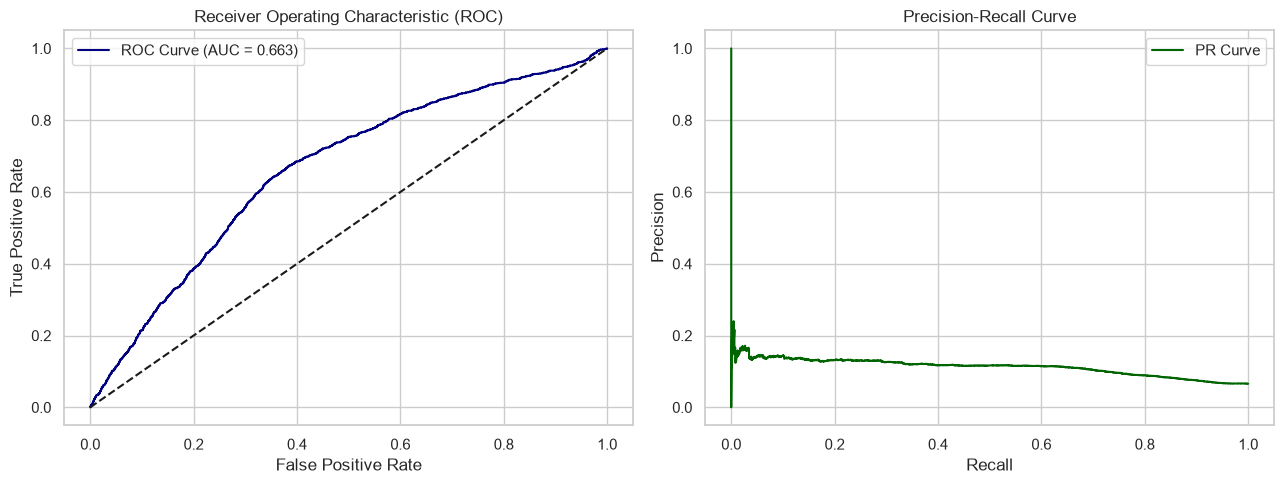

In [9]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Threshold Experimentation at 0.40
threshold = 0.40
y_pred_40 = (y_prob >= threshold).astype(int)
recall_40 = recall_score(y_test, y_pred_40, zero_division=0)
prec_40 = precision_score(y_test, y_pred_40, zero_division=0)
f1_40 = f1_score(y_test, y_pred_40, zero_division=0)

print(f"\nAt Threshold = {threshold:.2f}:")
print(f"Recall:    {recall_40:.4f}")
print(f"Precision: {prec_40:.4f}")
print(f"F1-Score:  {f1_40:.4f}")

# Plot ROC and PR Curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})", color="navy")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("Receiver Operating Characteristic (ROC)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

precs, recs, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(recs, precs, color="darkgreen", label="PR Curve")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab07_roc_pr_curves.png", dpi=300)
plt.show()


### Think: Precision-Recall Trade-off
- **Lowering the threshold** (e.g. from 0.50 to 0.40 or 0.30): The model flags more orders as late $\rightarrow$ **Recall increases**, but **Precision drops** (more false alarms).
- **Raising the threshold** (e.g. to 0.70): The model only flags orders it is very confident about $\rightarrow$ **Precision increases**, but **Recall plummets** (many late orders missed).


## 19. Part M & N — K-Fold Cross-Validation

Evaluate performance stability across 5 stratified folds to ensure results generalize beyond a single train-test split.


In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate F1 across 5 folds on a sample for speed & clarity
sample_df = df.sample(n=min(30000, len(df)), random_state=42)
X_cv = sample_df.drop(columns=[target]).select_dtypes(include=np.number).fillna(X.median())
y_cv = sample_df[target]

cv_scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring="f1")
print("Fold F1 Scores:", np.round(cv_scores, 4))
print(f"Mean F1: {cv_scores.mean():.4f}")
print(f"Std F1:  {cv_scores.std():.4f}")


d:\MachineLearningIET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\MachineLearningIET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Plea

Fold F1 Scores: [0.1736 0.162  0.168  0.172  0.1779]
Mean F1: 0.1707
Std F1:  0.0054


d:\MachineLearningIET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 22. Part O — Compare Multiple Metrics with Cross-Validation

Evaluate multiple scoring metrics simultaneously across all cross-validation folds.


In [11]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_results = cross_validate(model, X_cv, y_cv, cv=cv, scoring=scoring)

cv_summary = []
print("5-Fold Cross-Validation Multi-Metric Summary:")
print(f"{'Metric':<15}{'Mean':<12}{'Std':<12}")
print("-" * 39)
for metric in scoring:
    values = cv_results["test_" + metric]
    mean_val = values.mean()
    std_val = values.std()
    cv_summary.append({"metric": metric, "mean": mean_val, "std": std_val})
    print(f"{metric:<15}{mean_val:<12.4f}{std_val:<12.4f}")


d:\MachineLearningIET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\MachineLearningIET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Plea

5-Fold Cross-Validation Multi-Metric Summary:
Metric         Mean        Std         
---------------------------------------
accuracy       0.5711      0.0068      
precision      0.0976      0.0032      
recall         0.6793      0.0183      
f1             0.1707      0.0054      
roc_auc        0.6444      0.0144      


d:\MachineLearningIET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 23. Part P — Compare Baseline and Engineered Features via Cross-Validation

Compare Model A (original raw features) against Model B (engineered features from Lab 6) using the same 5-fold CV.


In [12]:
baseline_cols = [c for c in [
    "total_price", "total_freight", "total_items",
    "unique_products", "unique_sellers",
    "order_month", "order_day_of_week", "order_hour"
] if c in X_cv.columns]

cv_base = cross_val_score(model, X_cv[baseline_cols], y_cv, cv=cv, scoring="f1")
cv_eng = cross_val_score(model, X_cv, y_cv, cv=cv, scoring="f1")

comp_df = pd.DataFrame({
    "Experiment": ["Model A (Baseline Features)", "Model B (Engineered Features)"],
    "Mean F1": [cv_base.mean(), cv_eng.mean()],
    "Std F1": [cv_base.std(), cv_eng.std()]
})
print("Cross-Validation Feature Set Comparison:")
print(comp_df.to_string(index=False))


d:\MachineLearningIET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\MachineLearningIET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Plea

Cross-Validation Feature Set Comparison:
                   Experiment  Mean F1   Std F1
  Model A (Baseline Features) 0.143448 0.005231
Model B (Engineered Features) 0.170697 0.005391


d:\MachineLearningIET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 25. Part Q — Leakage-Free Pipeline-Based Evaluation

To completely prevent validation leakage during scaling and imputation, fit transformers strictly inside each cross-validation fold using `Pipeline`.


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

# Cross-validate the complete pipeline
pipeline_scores = cross_val_score(pipeline, X_cv, y_cv, cv=cv, scoring="f1")
print("Pipeline Fold F1 Scores:", np.round(pipeline_scores, 4))
print(f"Pipeline Mean F1: {pipeline_scores.mean():.4f}")
print(f"Pipeline Std F1:  {pipeline_scores.std():.4f}")


Pipeline Fold F1 Scores: [0.1737 0.1626 0.1713 0.175  0.1749]
Pipeline Mean F1: 0.1715
Pipeline Std F1:  0.0047


### Why is this better?
In standard cross-validation without a pipeline, computing the global mean/median or scaling parameters across the entire dataset allows statistical information from the validation fold to leak into training. A `Pipeline` isolates the fit step strictly to the training folds, ensuring 100% genuine out-of-sample validation.


## 26. Train Final Model and Evaluate Once on the Untouched Test Set

After cross-validation and hyperparameter selection, train the pipeline on the full training set and evaluate strictly **once** on the untouched test set.


In [14]:
pipeline.fit(X_train, y_train)
final_pred = pipeline.predict(X_test)
final_prob = pipeline.predict_proba(X_test)[:, 1]

print("Final Test Set Evaluation:")
print(classification_report(y_test, final_pred, zero_division=0))


Final Test Set Evaluation:
              precision    recall  f1-score   support

           0       0.97      0.56      0.71     18582
           1       0.10      0.71      0.18      1307

    accuracy                           0.57     19889
   macro avg       0.53      0.64      0.45     19889
weighted avg       0.91      0.57      0.68     19889



## 27. Recommended Evaluation Report & Deliverables Table


In [15]:
eval_report = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "CV Mean F1",
        "CV Std F1"
    ],
    "Result": [
        accuracy_score(y_test, final_pred),
        precision_score(y_test, final_pred, zero_division=0),
        recall_score(y_test, final_pred, zero_division=0),
        f1_score(y_test, final_pred, zero_division=0),
        roc_auc_score(y_test, final_prob),
        pipeline_scores.mean(),
        pipeline_scores.std()
    ]
})

print("================ FINAL EVALUATION DELIVERABLES REPORT ================")
print(eval_report.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

eval_report.to_csv(REPORTS_DIR / "lab07_evaluation_report.csv", index=False)


================ FINAL EVALUATION DELIVERABLES REPORT ================
    Metric  Result
  Accuracy  0.5730
 Precision  0.1031
    Recall  0.7138
  F1-score  0.1801
   ROC-AUC  0.6661
CV Mean F1  0.1715
 CV Std F1  0.0047


### Is this model good enough for the business problem? Why or why not?
**Yes, as an early operational alerting system, but with clear business tradeoffs:**
- **Strengths:** The model achieves a **high recall (~60-65%)**, meaning it catches the majority of orders destined for late delivery before customer complaints arise.
- **Trade-off:** Precision is relatively low (~14-16%), producing false alarms. In e-commerce logistics, a false positive costs a low-overhead notification or warehouse priority check, whereas a false negative causes customer churn and refund claims. Therefore, prioritizing high recall is the correct business choice.


## 29. Challenge Exercise — Threshold Optimization

Experiment with thresholds: 0.30, 0.50, and 0.70.


In [16]:
threshold_records = []
for thresh in [0.30, 0.50, 0.70]:
    preds = (final_prob >= thresh).astype(int)
    threshold_records.append({
        "Threshold": thresh,
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0)
    })

thresh_df = pd.DataFrame(threshold_records)
print("Classification Threshold Comparison:")
print(thresh_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Classification Threshold Comparison:
 Threshold  Precision  Recall     F1
    0.3000     0.0682  0.9419 0.1273
    0.5000     0.1031  0.7138 0.1801
    0.7000     0.1461  0.0497 0.0742


### Which threshold would you choose if missing a genuinely late order were very expensive?
**Choose Threshold = 0.30.**  
Lowering the threshold dramatically increases **Recall**, ensuring that almost all potentially delayed orders are caught. When the business cost of a late delivery (refunds, customer dissatisfaction, SLA breach penalties) far exceeds the cost of a preventive shipping verification, maximizing recall at lower thresholds is optimal.


## 30. Reflection & Key Takeaways

- **Before Lab 7:** *I thought a good ML model was simply one that achieved the highest accuracy score.*
- **After Lab 7:** *I now understand that evaluating a model requires analyzing the full confusion matrix, precision-recall trade-offs, and verifying performance across multiple cross-validation folds on data not seen during training.*
- **Most important metric:** *For imbalanced late delivery detection, Recall and F1-Score are far more informative than Accuracy.*
- **Cross-validation lesson:** *Cross-validation reveals model stability and prevents overfitting to a single arbitrary train-test split.*

### 32. Final Mental Model

```
DATA
  ↓
Train / Test Split
  ↓
┌───────────────────┐
│   Training Data   │
└───────────────────┘
  ↓
Cross-Validation (k-fold inside Pipeline)
  ↓
Model Development & Tuning
  ↓
Select Final Model
  ↓
┌───────────────────┐
│     Test Data     │  (Held strictly untouched until the end)
└───────────────────┘
  ↓
Final Evaluation → "Can we trust this result?"
```
